Gefundene Dateien:
  Sascha_HCL_1.CSV
  Sascha_Luft_1.CSV
  Sascha_Luft_16.CSV
  Sascha_Luft_8.CSV

--- Versuche Datei zu laden: Sascha_HCL_1.CSV ---
  Whitespace-Parser: shape = (25709, 1)
  Komma-Parser: shape = (25709, 2)
  Verwendete Daten-Shape: (25709, 2)
   Wellenzahl  Absorption
0     400.078    0.014448
1     400.257    0.015240
2     400.436    0.015532
3     400.615    0.015309
4     400.794    0.014843


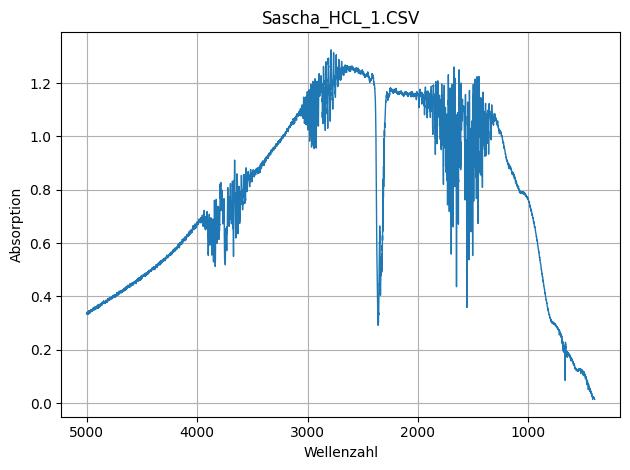


--- Versuche Datei zu laden: Sascha_Luft_1.CSV ---
  Whitespace-Parser: shape = (25709, 1)
  Komma-Parser: shape = (25709, 2)
  Verwendete Daten-Shape: (25709, 2)
   Wellenzahl  Absorption
0     400.078    0.013277
1     400.257    0.013597
2     400.436    0.013961
3     400.615    0.014243
4     400.794    0.014460


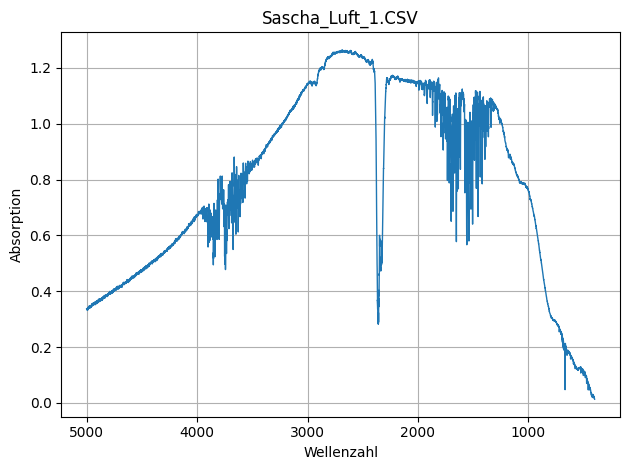


--- Versuche Datei zu laden: Sascha_Luft_16.CSV ---
  Whitespace-Parser: shape = (1607, 1)
  Komma-Parser: shape = (1607, 2)
  Verwendete Daten-Shape: (1607, 2)
   Wellenzahl  Absorption
0      400.79    0.013939
1      403.66    0.016091
2      406.52    0.017981
3      409.38    0.019426
4      412.24    0.020500


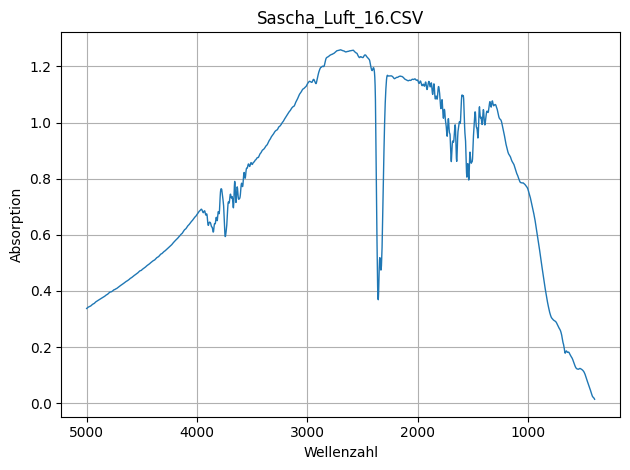


--- Versuche Datei zu laden: Sascha_Luft_8.CSV ---
  Whitespace-Parser: shape = (3214, 1)
  Komma-Parser: shape = (3214, 2)
  Verwendete Daten-Shape: (3214, 2)
   Wellenzahl  Absorption
0      400.79    0.012753
1      402.23    0.014110
2      403.66    0.015429
3      405.09    0.016688
4      406.52    0.017895


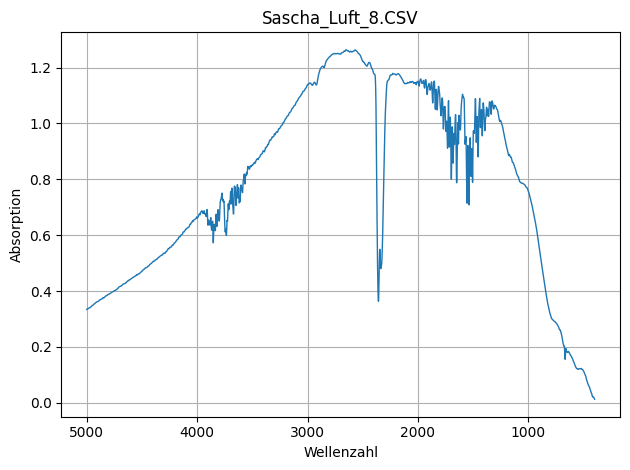

In [12]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

eingabe_ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Physikalische Chemie II/Experiment_5_IR-Spektroskopie/Messungen"

pfade = glob.glob(os.path.join(eingabe_ordner, "*.CSV"))
pfade.sort()

print("Gefundene Dateien:")
for p in pfade:
    print(" ", os.path.basename(p))


def lade_ir_datei(pfad):
    """Versuche, die Datei mit verschiedenen Separators einzulesen."""
    print(f"\n--- Versuche Datei zu laden: {os.path.basename(pfad)} ---")

    # 1) Versuch: Whitespace-getrennt (Leerzeichen/Tab)
    for sep, desc in [(r"\s+", "Whitespace"), (",", "Komma"), (";", "Semikolon")]:
        try:
            df = pd.read_csv(
                pfad,
                sep=sep,
                decimal=".",   # Punkt als Dezimaltrennzeichen
                header=None,
                engine="python"
            )
        except Exception as e:
            print(f"  {desc}-Parser Fehler: {e}")
            continue

        print(f"  {desc}-Parser: shape = {df.shape}")

        # Wenn mindestens 2 Spalten → wir nehmen das
        if df.shape[1] >= 2:
            return df

    # Wenn wir hier ankommen, haben wir keine geeignete Variante gefunden
    print("  ❌ Konnte keine Variante mit ≥2 Spalten finden.")
    return None


for pfad in pfade:
    df = lade_ir_datei(pfad)
    if df is None:
        # Datei überspringen
        continue

    # Die ersten beiden Spalten als x,y nehmen
    df = df.iloc[:, :2]
    df.columns = ["Wellenzahl", "Absorption"]
    df = df.dropna()

    print("  Verwendete Daten-Shape:", df.shape)
    print(df.head())

    # Plot
    plt.figure()
    plt.plot(df["Wellenzahl"], df["Absorption"], linewidth=1)
    plt.xlabel("Wellenzahl")
    plt.ylabel("Absorption")
    plt.title(os.path.basename(pfad))
    plt.grid(True)

    plt.gca().invert_xaxis()

    plt.tight_layout()
    plt.show()